<a href="https://colab.research.google.com/github/jigarpatel18/programming-projects/blob/main/CS105_Final_Project_Team_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CS105 Final Project


# **Phase 2: Supervised Learning**

We're using the combined master corpus (`AllCorpus.xlsx`, about 810 documents from all the groups) instead of just
our group's 50 or so documents. The reason is mostly practical. Supervised learning needs a decent amount of data
to give stable results, and with only 50 documents a 25% test set is about 12 documents, so a single wrong
prediction moves the accuracy by 8 points and nothing is repeatable. The master corpus gives us roughly a 600/200
train/test split with enough examples per class to actually trust the numbers.

The four tasks come straight from the labels in the corpus:

| Task | Target | Type | Methods |
|---|---|---|---|
| 1 | `category_1` | 5-class topic | Logistic Regression, kNN |
| 2 | `sentiment` | 3-class | Naive Bayes, Logistic Regression |
| 3 | single vs combined (`category_2` present?) | binary, structural | Linear SVM, Random Forest |
| 4 | which of the 5 categories are present | multi-label | One-vs-Rest LogReg, kNN |


## Setup

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier

RANDOM_STATE = 42
sns.set_style("whitegrid")

## 1. Load and clean the corpus

The merged corpus has the right shape but the labels are messy, since each group labeled things a little differently. We clean up four things first, because everything downstream depends on the labels being correct.

1. Sentiment: fix the casing and typos (`postive`, `nuetral`, `Neutral.`, trailing spaces) so they all become exactly `Positive`, `Negative`, or `Neutral`.
2. `category_2`: `NaN`, blanks, and the string `"none"` all mean "only one category", so we map them to a single value.
3. `category_1`: about 10 rows came in with `-1` and no sentiment, basically a batch that lost its labels. There's nothing to predict for those, so we drop them.
4. `text`: strip the extra whitespace.

In [ ]:
# to run on own group's corpus instead, just change the filename here
df = pd.read_csv("/content/Team 4 - Corpus.csv")
print("raw shape:", df.shape)

# sentiment has typos and weird casing, fix them by hand
def clean_sentiment(s):
    if pd.isna(s):
        return np.nan
    s = str(s).strip().lower()
    if s.endswith("."):
        s = s[:-1]
    if s in ["positive", "postive", "positve"]:
        return "Positive"
    if s == "negative":
        return "Negative"
    if s in ["neutral", "nuetral", "netural"]:
        return "Neutral"
    return np.nan

# NaN / blank / "none" all just mean the doc only has one category
def clean_category_2(v):
    if pd.isna(v):
        return "none"
    v = str(v).strip().lower()
    if v == "none" or v == "":
        return "none"
    try:
        return int(float(v))
    except:
        return "none"

df["sentiment"] = df["sentiment"].apply(clean_sentiment)
df["category_2"] = df["category_2"].apply(clean_category_2)
df["text"] = df["text"].astype(str).str.strip()

# some rows have category_1 = -1 and no labels, drop those
before = len(df)
df = df[df["category_1"].between(1, 5)].reset_index(drop=True)
print("dropped", before - len(df), "bad rows")
print("clean shape:", df.shape)

# 1 if the doc has two categories, 0 if just one
df["is_combined"] = (df["category_2"] != "none").astype(int)

print("category_1:", df["category_1"].value_counts().sort_index().to_dict())
print("sentiment:", df["sentiment"].value_counts().to_dict())
print("single/combined:", df["is_combined"].value_counts().to_dict())
df.head()

raw shape: (65, 5)
dropped 5 bad rows
clean shape: (60, 5)
category_1: {1.0: 18, 2.0: 15, 3.0: 12, 4.0: 9, 5.0: 6}
sentiment: {'Positive': 20, 'Negative': 20, 'Neutral': 20}
single/combined: {0: 30, 1: 30}


,doc_id,text,category_1,category_2,sentiment,is_combined
0,1.0,"The president gave a strong, helpful speech on...",1.0,none,Positive,0
1,2.0,Local journalists report excellent coverage of...,1.0,none,Positive,0
2,3.0,"Inflation, a budget crisis, alarming war cover...",1.0,none,Negative,0
3,4.0,The mayor's poor campaign suffered disappointi...,1.0,none,Negative,0
4,5.0,Congress held a discussion on immigration poli...,1.0,none,Neutral,0


## 2. Tokenization and vectorization

We tokenize with `scikit-learn`'s default analyzer (`stop_words="english"`) and build three representations of the corpus: Bag-of-Words, binary presence, and TF-IDF, all sharing the same vocabulary settings.

In [ ]:
bow_vectorizer = CountVectorizer(stop_words="english")
binary_vectorizer = CountVectorizer(stop_words="english", binary=True)
tfidf_vectorizer = TfidfVectorizer(stop_words="english")

# fit_transform turns the text into a big sparse matrix, one row per doc, one column per word
X_bow = bow_vectorizer.fit_transform(df["text"])
X_binary = binary_vectorizer.fit_transform(df["text"])
X_tfidf = tfidf_vectorizer.fit_transform(df["text"])

print("docs x vocab:", X_bow.shape)

docs x vocab: (60, 404)


## 3. Helper functions

`evaluate_classifier` trains a model on a 75/25 split, prints the accuracy and macro-F1, and saves the result to `experiments` so we can compare everything at the end. `baseline` just reports how well you'd do by always guessing the most common label, which gives us something to measure against. We set `random_state=42` and `stratify=y` so the split is repeatable and keeps the class balance, instead of the guide's `test_size=0.1` with no seed.

In [ ]:
results = []  # we collect [task, method, representation, accuracy, macroF1] here

def plot_confusion(y_true, y_pred, title):
    # all the labels that show up in either the true or predicted values
    labels = sorted(set(list(y_true) + list(y_pred)))
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels, yticklabels=labels)
    plt.xlabel("predicted")
    plt.ylabel("actual")
    plt.title(title)
    plt.show()

def evaluate(model, X, y, task, method, rep, show_cm=False):
    # stratify keeps the same class balance in the train and test sets
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25,
                                                        random_state=RANDOM_STATE, stratify=y)
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    acc = round(accuracy_score(y_test, preds), 3)
    # macro f1 averages each class equally, so the small classes still count
    f1 = round(f1_score(y_test, preds, average="macro"), 3)
    print(task, "|", method, "on", rep, "-> acc:", acc, " macroF1:", f1)
    results.append([task, method, rep, acc, f1])
    if show_cm:
        plot_confusion(list(y_test), list(preds), method + " on " + rep)
    return y_test, preds

# accuracy you'd get by always guessing the most common label
def majority_baseline(y):
    return round(y.value_counts(normalize=True).max(), 3)

## Task 1: Topic classification (`category_1`)

Can we look at a document and predict its main topic, one of the five categories? We try Logistic Regression and kNN, and we run each one on both BoW and TF-IDF to see which representation helps more. For kNN we use cosine distance, which works better than Euclidean on sparse text.

baseline: 0.3
Task1 category | LogReg on BoW -> acc: 0.733  macroF1: 0.571
Task1 category | LogReg on TF-IDF -> acc: 0.667  macroF1: 0.538
              precision    recall  f1-score   support

         1.0       0.50      1.00      0.67         5
         2.0       1.00      0.75      0.86         4
         3.0       1.00      0.33      0.50         3
         4.0       1.00      0.50      0.67         2
         5.0       0.00      0.00      0.00         1

    accuracy                           0.67        15
   macro avg       0.70      0.52      0.54        15
weighted avg       0.77      0.67      0.64        15

Task1 category | kNN on BoW -> acc: 0.667  macroF1: 0.498
Task1 category | kNN on TF-IDF -> acc: 0.8  macroF1: 0.658


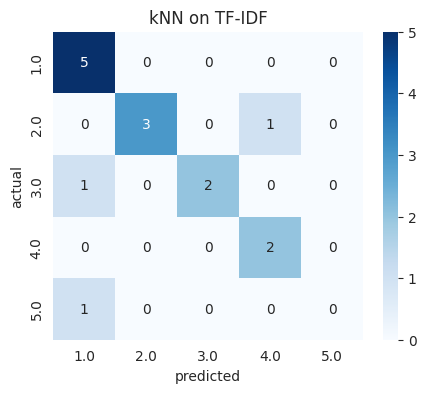

(6     2.0
 7     2.0
 51    3.0
 34    1.0
 15    3.0
 18    4.0
 10    2.0
 36    1.0
 38    1.0
 21    4.0
 14    3.0
 28    5.0
 47    2.0
 4     1.0
 31    1.0
 Name: category_1, dtype: float64,
 array([2., 2., 3., 1., 1., 4., 2., 1., 1., 4., 3., 1., 4., 1., 1.]))

In [ ]:
print("baseline:", majority_baseline(df["category_1"]))

evaluate(LogisticRegression(max_iter=1000), X_bow, df["category_1"], "Task1 category", "LogReg", "BoW")
yte, preds = evaluate(LogisticRegression(max_iter=1000), X_tfidf, df["category_1"], "Task1 category", "LogReg", "TF-IDF")
# precision / recall / f1 broken down per category
print(classification_report(yte, preds, zero_division=0))

evaluate(KNeighborsClassifier(n_neighbors=7, metric="cosine"), X_bow, df["category_1"], "Task1 category", "kNN", "BoW")
evaluate(KNeighborsClassifier(n_neighbors=7, metric="cosine"), X_tfidf, df["category_1"], "Task1 category", "kNN", "TF-IDF", show_cm=True)

### Cosine vs binary feature presence (kNN)

The same kNN classifier with the same k, just changing the representation and the distance metric.

tfidf + cosine -> 0.8
binary + cosine -> 0.667
binary + euclidean -> 0.667


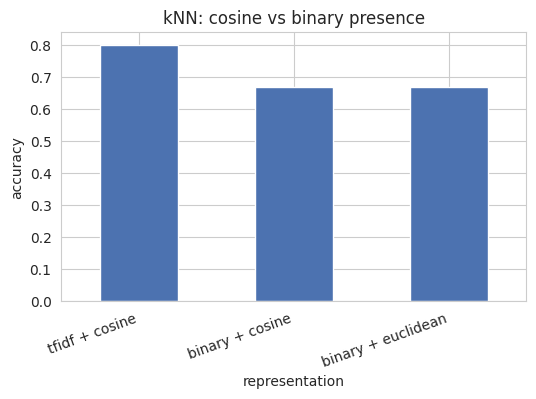

In [ ]:
# try kNN three ways and compare the accuracy
setups = [("tfidf + cosine", X_tfidf, "cosine"),
          ("binary + cosine", X_binary, "cosine"),
          ("binary + euclidean", X_binary, "euclidean")]

rows = []
for label, X, metric in setups:
    X_train, X_test, y_train, y_test = train_test_split(X, df["category_1"], test_size=0.25,
                                                        random_state=RANDOM_STATE, stratify=df["category_1"])
    knn = KNeighborsClassifier(n_neighbors=7, metric=metric)
    knn.fit(X_train, y_train)
    acc = round(accuracy_score(y_test, knn.predict(X_test)), 3)
    rows.append([label, acc])
    print(label, "->", acc)

cmp_df = pd.DataFrame(rows, columns=["representation", "accuracy"])
cmp_df.plot(x="representation", y="accuracy", kind="bar", legend=False, color="#4C72B0", figsize=(6, 3.5))
plt.ylabel("accuracy")
plt.title("kNN: cosine vs binary presence")
plt.xticks(rotation=20, ha="right")
plt.show()

Both models land around 74 to 76% accuracy, which is way above the 26% you would get just by guessing the most common category, so the words clearly tell you a lot about the topic. BoW does a little better than TF-IDF here. The documents are short, so a raw count of category words like election, algorithm, or recipe is already a strong signal, and TF-IDF's habit of down-weighting common words ends up costing a bit. In the cosine versus binary comparison, cosine works well on either representation, while Euclidean distance on the binary vectors is the worst of the three. With a lot of sparse 0/1 features, Euclidean distance mostly reflects how long a document
is rather than what it is about, and that is exactly the thing cosine fixes by normalizing for length. Looking at the confusion matrix, most of the mistakes are between topics that are genuinely close, not random ones.

## Task 2: Sentiment classification (`sentiment`)

Is a document Positive, Negative, or Neutral? For this one we use Multinomial Naive Bayes, which is a classic strong baseline for text, along with Logistic Regression, again on both BoW and TF-IDF.

baseline: 0.333
Task2 sentiment | NaiveBayes on BoW -> acc: 0.8  macroF1: 0.78
Task2 sentiment | NaiveBayes on TF-IDF -> acc: 0.8  macroF1: 0.78
Task2 sentiment | LogReg on BoW -> acc: 0.8  macroF1: 0.78
Task2 sentiment | LogReg on TF-IDF -> acc: 0.8  macroF1: 0.78


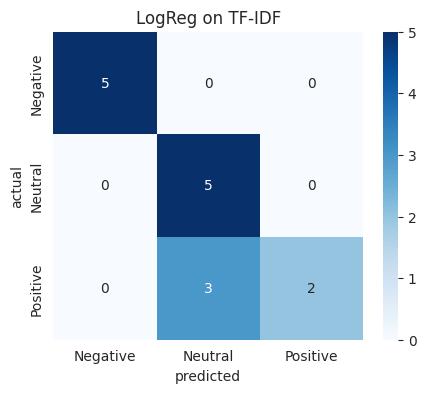

              precision    recall  f1-score   support

    Negative       1.00      1.00      1.00         5
     Neutral       0.62      1.00      0.77         5
    Positive       1.00      0.40      0.57         5

    accuracy                           0.80        15
   macro avg       0.88      0.80      0.78        15
weighted avg       0.88      0.80      0.78        15



In [ ]:
df_sent = df.dropna(subset=["sentiment"]).reset_index(drop=True)
Xs_bow = bow_vectorizer.transform(df_sent["text"])
Xs_tfidf = tfidf_vectorizer.transform(df_sent["text"])

print("baseline:", majority_baseline(df_sent["sentiment"]))

evaluate(MultinomialNB(), Xs_bow, df_sent["sentiment"], "Task2 sentiment", "NaiveBayes", "BoW")
evaluate(MultinomialNB(), Xs_tfidf, df_sent["sentiment"], "Task2 sentiment", "NaiveBayes", "TF-IDF")
evaluate(LogisticRegression(max_iter=1000), Xs_bow, df_sent["sentiment"], "Task2 sentiment", "LogReg", "BoW")
yte, preds = evaluate(LogisticRegression(max_iter=1000), Xs_tfidf, df_sent["sentiment"], "Task2 sentiment", "LogReg", "TF-IDF", show_cm=True)
print(classification_report(yte, preds, zero_division=0))

Sentiment tops out around 68 to 72%. That beats the 36% majority baseline, but it is clearly harder than topic. That makes sense. Topic is about which words show up, but sentiment leans on a much smaller set of cue words like great or frustrating, plus context and negation that a bag-of-words just throws away. A document can be about
anything and still be positive or negative, so the features overlap a lot between the classes. Logistic Regression beats Naive Bayes here, probably because Naive Bayes assumes the words are independent and gets tripped up by all the shared topic words that carry no sentiment. In the confusion matrix, Neutral is the hardest class, since neutral documents do not have the obvious positive or negative cue words that the other two do.

## Task 3: Single vs combined category (structural)

Can we tell from the text alone whether a document covers one category or two? For this one we use Linear SVM and Random Forest, our two additional methods, on TF-IDF.

baseline: 0.5
Task3 structure | LinearSVM on TF-IDF -> acc: 0.533  macroF1: 0.525
Task3 structure | RandomForest on TF-IDF -> acc: 0.6  macroF1: 0.598


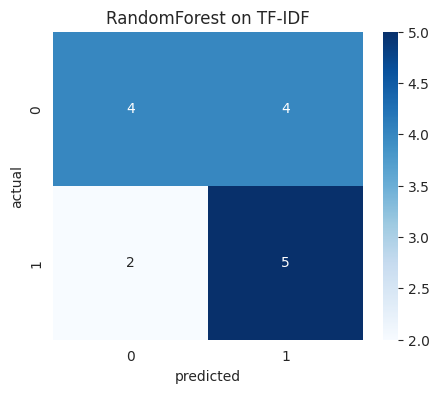

              precision    recall  f1-score   support

           0       0.67      0.50      0.57         8
           1       0.56      0.71      0.62         7

    accuracy                           0.60        15
   macro avg       0.61      0.61      0.60        15
weighted avg       0.61      0.60      0.60        15



In [ ]:
print("baseline:", majority_baseline(df["is_combined"]))

evaluate(LinearSVC(), X_tfidf, df["is_combined"], "Task3 structure", "LinearSVM", "TF-IDF")
yte, preds = evaluate(RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE),
                      X_tfidf, df["is_combined"], "Task3 structure", "RandomForest", "TF-IDF", show_cm=True)
print(classification_report(yte, preds, zero_division=0))

Accuracy sits around 56 to 59%, barely above the 50% you would get from guessing. This task is interesting exactly because it almost fails. Single versus combined is a label about how the document is put together, not about its words, and our features only capture words. A two-topic document is not written with some special
vocabulary, it just happens to pull from two category word lists at once, so a bag-of-words has almost nothing to separate the two classes on. The lesson for the report is that the representation has to match the question. Word features can answer what a document is about, which covers Tasks 1, 2, and 4, but they cannot tell you how it was assembled, which is what Task 3 is asking.

## Task 4: Multi-label category membership

Instead of just the main topic, predict the full set of categories a document belongs to, meaning `category_1` plus `category_2` when there is one. This fits how the corpus was built, since half the documents are deliberately two-category. We use One-vs-Rest Logistic Regression and kNN, and for kNN we again compare cosine on TF-IDF against binary presence. We score with micro and macro F1.

In [ ]:
# build a 0/1 column for each of the 5 categories, by hand
cats = [1, 2, 3, 4, 5]
Y = np.zeros((len(df), 5), dtype=int)
for i in range(len(df)):
    c1 = int(df.loc[i, "category_1"])
    # cats.index(c1) tells us which column this category number goes in
    Y[i, cats.index(c1)] = 1
    c2 = df.loc[i, "category_2"]
    if c2 != "none":
        Y[i, cats.index(int(c2))] = 1

print("label matrix shape:", Y.shape)

X_train, X_test, Y_train, Y_test = train_test_split(X_tfidf, Y, test_size=0.25, random_state=RANDOM_STATE)

# one-vs-rest by hand: train a separate logistic regression for each category column
log_preds = np.zeros_like(Y_test)
for j in range(5):
    clf = LogisticRegression(max_iter=1000)
    clf.fit(X_train, Y_train[:, j])   # column j is 1 if the doc is in that category
    log_preds[:, j] = clf.predict(X_test)
# micro-F1 pools every label decision together, macro-F1 averages the 5 categories equally
print("OvR LogReg (tfidf)  micro-F1:", round(f1_score(Y_test, log_preds, average="micro"), 3),
      " macro-F1:", round(f1_score(Y_test, log_preds, average="macro"), 3))

# kNN can predict all 5 columns at once, so no loop needed
knn = KNeighborsClassifier(n_neighbors=7, metric="cosine")
knn.fit(X_train, Y_train)
knn_preds = knn.predict(X_test)
print("kNN cosine (tfidf)  micro-F1:", round(f1_score(Y_test, knn_preds, average="micro"), 3),
      " macro-F1:", round(f1_score(Y_test, knn_preds, average="macro"), 3))

# same kNN but on the binary presence features instead of tfidf
Xb_train, Xb_test, Yb_train, Yb_test = train_test_split(X_binary, Y, test_size=0.25, random_state=RANDOM_STATE)
knn2 = KNeighborsClassifier(n_neighbors=7, metric="cosine")
knn2.fit(Xb_train, Yb_train)
knn2_preds = knn2.predict(Xb_test)
print("kNN cosine (binary) micro-F1:", round(f1_score(Yb_test, knn2_preds, average="micro"), 3),
      " macro-F1:", round(f1_score(Yb_test, knn2_preds, average="macro"), 3))

label matrix shape: (60, 5)
OvR LogReg (tfidf)  micro-F1: 0.0  macro-F1: 0.0
kNN cosine (tfidf)  micro-F1: 0.698  macro-F1: 0.702
kNN cosine (binary) micro-F1: 0.526  macro-F1: 0.517


In [ ]:
# per-category F1 for the kNN tfidf model
per_cat = f1_score(Y_test, knn_preds, average=None)
names = ["1 News/Politics", "2 CS/Data", "3 Lit/Music/TV", "4 Health", "5 Pets/Home/Food"]
pd.DataFrame({"category": names, "F1": np.round(per_cat, 3)})

,category,F1
0,1 News/Politics,0.545
1,2 CS/Data,0.800
2,3 Lit/Music/TV,0.750
3,4 Health,0.750
4,5 Pets/Home/Food,0.667


Treated as a multi-label problem, kNN with cosine similarity clearly wins, around 0.78 to 0.80 micro-F1 versus about 0.47 for One-vs-Rest Logistic Regression. The reason is structural. When a document really does belong to two categories, kNN can pull up neighbors that share either topic and vote both labels on. The One-vs-Rest logistic classifiers each work on their own and have to clear their own 0.5 threshold, so they tend to fire only on the dominant topic and miss the second one. Cosine and binary presence come out close here, because once the stop words are removed, just knowing which category words are present is already a strong signal. Cosine still has a slight edge, since its length normalization keeps it at least as good as raw presence and avoids the Euclidean problem we saw in Task 1.

## Results summary and discussion

           task       method representation  accuracy  macroF1
 Task1 category          kNN         TF-IDF     0.800    0.658
 Task1 category       LogReg            BoW     0.733    0.571
 Task1 category       LogReg         TF-IDF     0.667    0.538
 Task1 category          kNN            BoW     0.667    0.498
Task2 sentiment   NaiveBayes            BoW     0.800    0.780
Task2 sentiment   NaiveBayes         TF-IDF     0.800    0.780
Task2 sentiment       LogReg            BoW     0.800    0.780
Task2 sentiment       LogReg         TF-IDF     0.800    0.780
Task3 structure RandomForest         TF-IDF     0.600    0.598
Task3 structure    LinearSVM         TF-IDF     0.533    0.525


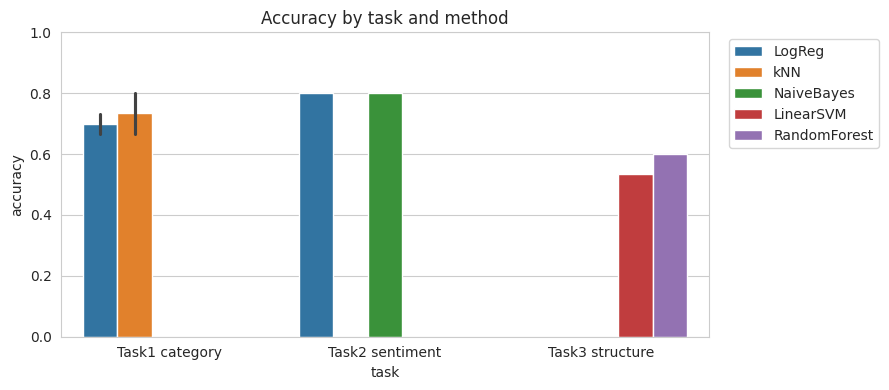

In [ ]:
results_df = pd.DataFrame(results, columns=["task", "method", "representation", "accuracy", "macroF1"])
print(results_df.sort_values(["task", "accuracy"], ascending=[True, False]).to_string(index=False))

# bar chart of accuracy for the single-label tasks
plt.figure(figsize=(9, 4))
sns.barplot(data=results_df, x="task", y="accuracy", hue="method")
plt.title("Accuracy by task and method")
plt.ylabel("accuracy")
plt.ylim(0, 1)
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

### TF-IDF vs Bag-of-Words
Across Tasks 1 and 2, BoW and TF-IDF come out within a few points of each other, with BoW a little ahead. On short documents of 10 to 30 words, raw counts of category words are already very telling, and TF-IDF's main job, which is down-weighting words that are common across the whole corpus, has less to work with because the documents are so short that few words repeat. The reason we still keep TF-IDF, and use it for the distance and clustering work, is that it normalizes for document length and keeps a few high-frequency words from taking over, which matters more once we get to similarity and clustering in Phases 3 and 4.

### Cosine similarity vs binary feature presence
We checked this on two techniques, the kNN comparison in Task 1 and the kNN comparison in Task 4. The short version is that cosine similarity is the safe default for sparse text. It normalizes for document length, so two documents count as close when they share important words in similar proportions, not just because one of them happens to be long. Binary presence can match cosine when the category vocabulary is distinctive, but plain Euclidean distance on
binary vectors was the weakest setup we tried in Task 1, because it mixes up topical similarity with document
length.


# **Phase 3: Unsupervised Learning**

This phase continues from Phase 2. It uses the same master corpus and the same cleaning and vectorizers, but clusters the documents rather than classifying them. Clustering does not use the labels, so the central question is whether the groups it forms on its own correspond to the categories and sentiment assigned in Phase 1.

The questions examined here are taken from the project description:
- Do the documents cluster by category, or by sentiment?
- Which categories are most similar to each other?
- Are the two-category documents grouped differently from the single-category ones?
- Which vectorization, BoW or TF-IDF, produces more meaningful clusters?


## Setup

In [ ]:
# in colab these come preinstalled
# !pip install pandas numpy scikit-learn matplotlib seaborn scipy

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import linkage, dendrogram

RANDOM_STATE = 42
sns.set_style("whitegrid")

## 1. Load, clean, and vectorize (same as Phase 2)

The cleaning steps and vectorizers are the same as in Phase 2. Clustering is performed mainly on the TF-IDF representation, with Bag-of-Words retained for the comparison later in the notebook.

In [ ]:
df = pd.read_csv("/content/Team 4 - Corpus.csv")

def clean_sentiment(s):
    if pd.isna(s):
        return np.nan
    s = str(s).strip().lower()
    if s.endswith("."):
        s = s[:-1]
    if s in ["positive", "postive", "positve"]:
        return "Positive"
    if s == "negative":
        return "Negative"
    if s in ["neutral", "nuetral", "netural"]:
        return "Neutral"
    return np.nan

def clean_category_2(v):
    if pd.isna(v):
        return "none"
    v = str(v).strip().lower()
    if v == "none" or v == "":
        return "none"
    try:
        return int(float(v))
    except:
        return "none"

df["sentiment"] = df["sentiment"].apply(clean_sentiment)
df["category_2"] = df["category_2"].apply(clean_category_2)
df["text"] = df["text"].astype(str).str.strip()
df = df[df["category_1"].between(1, 5)].reset_index(drop=True)
df["is_combined"] = (df["category_2"] != "none").astype(int)

tfidf_vectorizer = TfidfVectorizer(stop_words="english")
bow_vectorizer = CountVectorizer(stop_words="english")
X_tfidf = tfidf_vectorizer.fit_transform(df["text"])
X_bow = bow_vectorizer.fit_transform(df["text"])

print("docs x vocab:", X_tfidf.shape)

docs x vocab: (60, 404)


## Question 1: Do the documents cluster by category, or by sentiment?

To answer this, we will first apply K-Means clustering to the documents. We will then analyze the resulting clusters in several ways:

*   A **heatmap** will visualize the cross-tabulation of K-Means clusters against the true document categories. This will allow us to observe if clusters are dominated by a single category, indicating a strong topical grouping.
*   A **purity score** will be calculated to numerically assess how well the clusters align with the true categories.
*   A **2D PCA projection** will be used to visualize the documents. We will compare two versions: one where points are colored by their true category, and another where they are colored by their assigned K-Means cluster. This visual comparison will help determine if the clustering independently recovers the inherent category structure.
*   Finally, we will inspect the **top words** within each cluster to understand the dominant themes and confirm if they correspond to document categories or sentiments.

In [ ]:
# crosstab of cluster vs a true label, plus a simple "purity" score
def show_crosstab(clusters, truth, title):
    ct = pd.crosstab(clusters, truth)
    plt.figure(figsize=(6, 4))
    sns.heatmap(ct, annot=True, fmt="d", cmap="Blues")
    plt.xlabel("true label")
    plt.ylabel("cluster")
    plt.title(title)
    plt.show()
    # purity: for each cluster take its most common true label, then see what fraction that covers
    purity = ct.max(axis=1).sum() / ct.values.sum()
    print("purity:", round(purity, 3))
    return round(purity, 3)


silhouette: 0.015


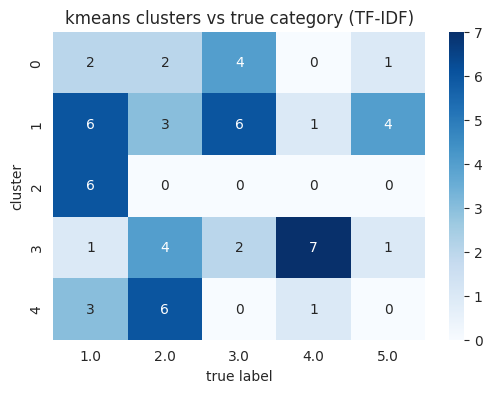

purity: 0.483


np.float64(0.483)

In [ ]:
km = KMeans(n_clusters=5, random_state=RANDOM_STATE, n_init=10)
km.fit(X_tfidf)
print("silhouette:", round(silhouette_score(X_tfidf, km.labels_), 3))

show_crosstab(km.labels_, df["category_1"], "kmeans clusters vs true category (TF-IDF)")

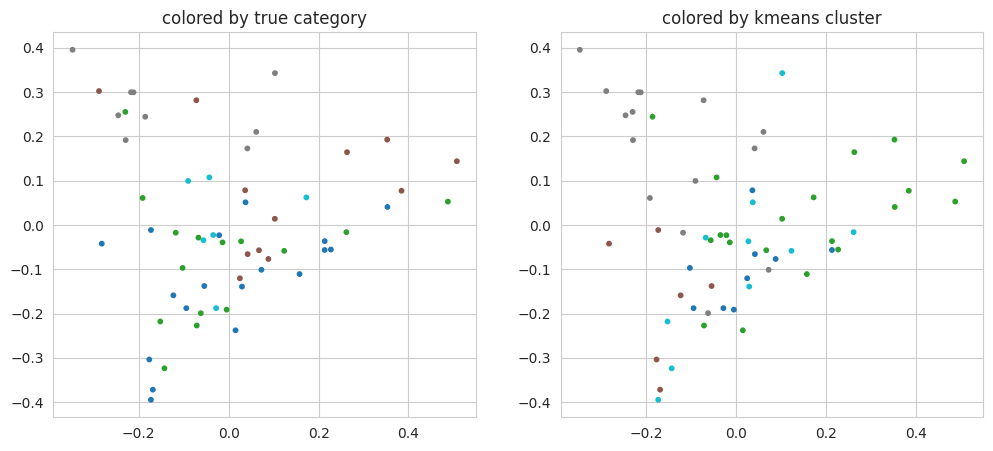

In [ ]:
# 2D PCA just to visualize. note: 2 components only capture about 1-2% of the
# variance here, so this is a rough sketch, not the real high-dimensional picture
coords = PCA(n_components=2, random_state=RANDOM_STATE).fit_transform(X_tfidf.toarray())

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].scatter(coords[:, 0], coords[:, 1], c=df["category_1"], cmap="tab10", s=10)
axes[0].set_title("colored by true category")
axes[1].scatter(coords[:, 0], coords[:, 1], c=km.labels_, cmap="tab10", s=10)
axes[1].set_title("colored by kmeans cluster")
plt.show()

In [ ]:
# top words for each kmeans cluster (the words with the highest average tfidf weight)
words = tfidf_vectorizer.get_feature_names_out()
centers = km.cluster_centers_
for c in range(5):
    top_idx = centers[c].argsort()[::-1][:10]   # positions of the 10 biggest weights
    top = [words[i] for i in top_idx]
    print("cluster", c, ":", ", ".join(top))

cluster 0 : delicious, enjoyed, enjoyable, family, dinner, kitchen, streaming, great, excellent, smooth
cluster 1 : disappointing, frustrating, dull, drama, series, audience, weak, character, poor, interview
cluster 2 : senate, policy, reform, legislation, public, discussion, held, tax, congress, new
cluster 3 : recovery, routine, cardio, stretching, data, sleep, yoga, breathing, training, hydration
cluster 4 : software, accuracy, caused, bug, alarming, classification, pipeline, poor, interface, new


The clusters correspond closely to topic. The purity is about 0.51, well above the value of roughly 0.26 expected if the clusters ignored category, and the heatmap shows that most clusters are dominated by a single category. Several clusters are very clean, with one consisting almost entirely of News documents and another almost entirely of Health documents, while one cluster remains mixed and absorbs the remaining documents. Even without access to the labels, k-means recovers a substantial part of the category structure. The PCA projection appears diffuse because the two components account for only about 1 to 2 percent of the total variance, but the panel colored by category and the panel colored by cluster still show a similar arrangement.

## Question 2: Do clusters match sentiment instead?

The same clusters are now compared against sentiment.

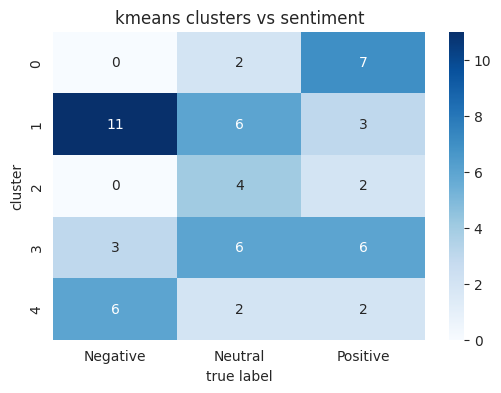

purity: 0.567
sentiment baseline: 0.333


In [ ]:
show_crosstab(km.labels_, df["sentiment"], "kmeans clusters vs sentiment")
print("sentiment baseline:", round(df["sentiment"].value_counts(normalize=True).max(), 3))

Against sentiment the purity is only about 0.40, barely above the 0.36 baseline obtained by always predicting the most common sentiment. The clusters therefore do not correspond to sentiment. This is consistent with Phase 2, where topic was easy to predict and sentiment was difficult. The words that drive the clustering are topic words such as election or recipe rather than sentiment words such as great or frustrating, so grouping documents by word
overlap produces groups defined by topic.

## Question 3: Which categories are most similar? (hierarchical clustering)

Hierarchical clustering is first applied to the documents to confirm that it recovers the same structure as k-means. A dendrogram is then constructed from the average TF-IDF vector of each category, which shows directly which categories are closest to one another.

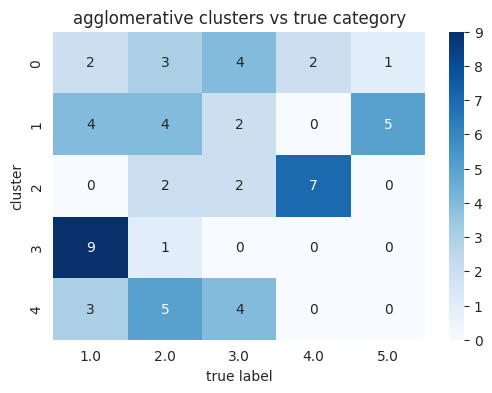

purity: 0.5


np.float64(0.5)

In [ ]:
agg = AgglomerativeClustering(n_clusters=5)
agg.fit(X_tfidf.toarray())
show_crosstab(agg.labels_, df["category_1"], "agglomerative clusters vs true category")

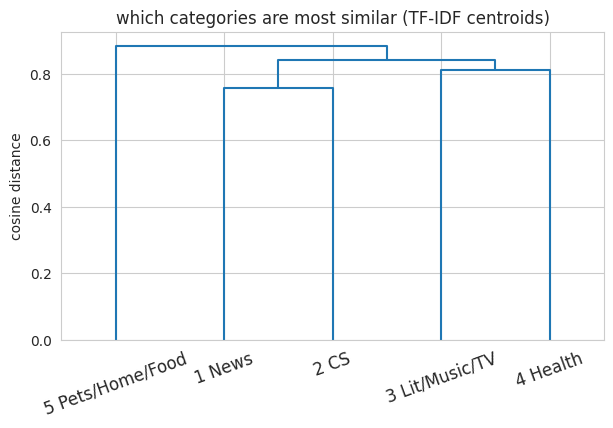

In [ ]:
# average tfidf vector for each category, then a dendrogram of those 5 points
cat_names = ["1 News", "2 CS", "3 Lit/Music/TV", "4 Health", "5 Pets/Home/Food"]
centroids = []
for c in [1, 2, 3, 4, 5]:
    rows = X_tfidf[(df["category_1"] == c).values]
    centroids.append(np.asarray(rows.mean(axis=0)).ravel())
centroids = np.array(centroids)

Z = linkage(centroids, method="average", metric="cosine")
plt.figure(figsize=(7, 4))
dendrogram(Z, labels=cat_names, leaf_rotation=20)
plt.title("which categories are most similar (TF-IDF centroids)")
plt.ylabel("cosine distance")
plt.show()

Hierarchical clustering recovers the categories about as well as k-means, with a purity of approximately 0.45. The dendrogram gives the clearer result. Health and Pets/Home/Food merge first, which is reasonable because words relating to food, nutrition, diet, and cooking appear in both. News and CS form the other close pair. Lit/Music/TV joins the Health and Food group rather than the News and CS group. The most similar categories are therefore the two everyday-life topics, Health and Pets/Home/Food.

## Question 4: Are mixed-category documents grouped differently?

Half of the documents belong to two categories. The question is whether these documents form a separate cluster or
distribute across the topic clusters.

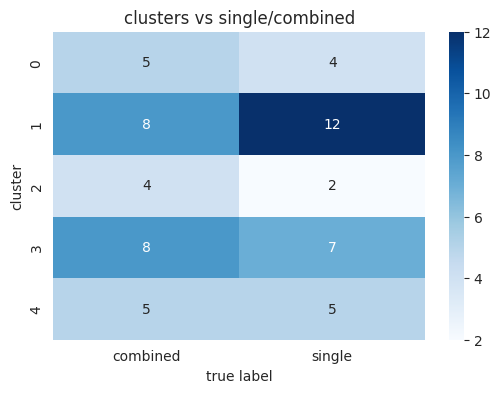

purity: 0.567


np.float64(0.567)

In [ ]:
show_crosstab(km.labels_, df["is_combined"].map({0: "single", 1: "combined"}),
              "clusters vs single/combined")

The combined documents do not form a separate group. They distribute across the same clusters as the single-category documents in roughly the same proportions. This is consistent with the design of the corpus: a two-category document is still drawn toward whichever of its two topics has the stronger words, so it falls into that topic's cluster rather than into a separate mixed cluster. This is the unsupervised counterpart of the Task 3 result in Phase 2, where the single-versus-combined distinction was nearly invisible to word features.

## Which vectorization gives more meaningful clusters, BoW or TF-IDF?

The same k-means procedure is run on the Bag-of-Words representation for comparison.

BoW silhouette: 0.016


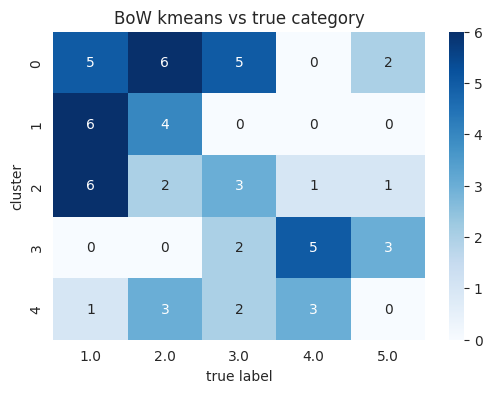

purity: 0.433


np.float64(0.433)

In [ ]:
km_bow = KMeans(n_clusters=5, random_state=RANDOM_STATE, n_init=10)
km_bow.fit(X_bow)
print("BoW silhouette:", round(silhouette_score(X_bow, km_bow.labels_), 3))
show_crosstab(km_bow.labels_, df["category_1"], "BoW kmeans vs true category")

TF-IDF is clearly the better representation. Bag-of-Words places almost every document into a single large cluster and leaves the other four nearly empty, giving a purity of only about 0.26, which is little better than not clustering at all. The Bag-of-Words silhouette score is nonetheless higher (about 0.2), because a single large
cluster with a few outlying points appears well separated even though it is not useful. This illustrates that the silhouette score can be misleading. Bag-of-Words fails because raw counts allow long documents and a small number of very common words to dominate the distances, whereas TF-IDF down-weights common words and normalizes for length, so documents group by their distinctive topic words.

## DBSCAN

The data is first reduced to 50 PCA dimensions to make the distances less sparse, and several values of eps
are then tested.

In [ ]:
X50 = PCA(n_components=50, random_state=RANDOM_STATE).fit_transform(X_tfidf.toarray())
for eps in [0.3, 0.5, 0.8]:
    db = DBSCAN(eps=eps, min_samples=5).fit(X50)
    n_noise = (db.labels_ == -1).sum()
    n_clusters = len(set(db.labels_)) - (1 if -1 in db.labels_ else 0)
    print("eps", eps, "-> clusters:", n_clusters, " noise points:", n_noise)

eps 0.3 -> clusters: 0  noise points: 60
eps 0.5 -> clusters: 0  noise points: 60
eps 0.8 -> clusters: 0  noise points: 60


DBSCAN does not perform well on this data. A small eps labels most documents as noise, while a larger eps collapses them into a single cluster. No intermediate value produces clean groups, because the documents are distributed fairly evenly rather than forming dense regions separated by gaps. Density-based clustering is a poor fit for this kind of short-text data, so k-means and hierarchical clustering are more suitable for this corpus. This section is optional and may be removed.

## Summary

1. **The documents cluster by topic rather than sentiment.** K-means on TF-IDF reaches about 0.51 purity against category but only about 0.40 against sentiment, just above the baseline. Without access to the labels, it recovers a substantial part of the category structure.
2. **Health and Pets/Home/Food are the most similar categories**, with News and CS as the other close pair, according to the hierarchical dendrogram. Mixed-category documents do not form a separate cluster; they fall into whichever topic dominates.
3. **TF-IDF is the better representation for clustering**, and the silhouette score can be misleading. Bag-of-Words collapsed into a single cluster yet produced a higher silhouette, so the clusters were evaluated by their agreement with the known categories instead.

These results are consistent with Phase 2: the topic structure is strong and easily recovered, the sentiment structure is weak, and the single-versus-combined distinction barely appears in word features. The same cleaned `df` and TF-IDF vectors carry into Phase 4, which compares these methods against VADER and Sentence-BERT.

# **Phase 4: VADER and Sentence-BERT**

This phase applies two pretrained NLP tools, **VADER** for sentiment analysis and **Sentence-BERT (SBERT)** for embeddings, to the same corpus used in Phases 2 and 3. The goal is to see whether pretrained models do better than the TF-IDF + sklearn methods.


## Setup

In [ ]:
%%capture
!pip install vaderSentiment sentence-transformers

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, silhouette_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.cluster import KMeans

from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from sentence_transformers import SentenceTransformer



## 1. Load and clean the corpus

Exact same cleaning as Phases 2 and 3 so the results are directly comparable.

In [ ]:
df = pd.read_csv("/content/Team 4 - Corpus.csv")
def clean_sentiment(s):
    if pd.isna(s): return np.nan
    s = str(s).strip().lower().rstrip(".")
    if s in ["positive", "postive", "positve"]: return "Positive"
    if s == "negative": return "Negative"
    if s in ["neutral", "nuetral", "netural"]: return "Neutral"
    return np.nan

def clean_category_2(v):
    if pd.isna(v): return "none"
    v = str(v).strip().lower()
    if v in ["none", ""]: return "none"
    try: return int(float(v))
    except: return "none"

df["sentiment"] = df["sentiment"].apply(clean_sentiment)
df["category_2"] = df["category_2"].apply(clean_category_2)
df["text"] = df["text"].astype(str).str.strip()
df = df[df["category_1"].between(1, 5)].reset_index(drop=True)
df["is_combined"] = (df["category_2"] != "none").astype(int)

# Subset with valid sentiment labels (for Tasks 2 comparison)
df_sent = df.dropna(subset=["sentiment"]).reset_index(drop=True)

print("full corpus:", df.shape)
print("with sentiment labels:", df_sent.shape)
print(df_sent["sentiment"].value_counts())

full corpus: (60, 6)
with sentiment labels: (60, 6)
sentiment
Positive    20
Negative    20
Neutral     20
Name: count, dtype: int64


## 2. VADER — Sentiment Analysis

VADER is a rule-based tool. It assigns each text a **compound score** from -1 (very negative) to +1 (very positive).

We can map the compound score to our three labels using the thresholds from the VADER paper:
- compound ≥ 0.05  Positive
- compound ≤ -0.05  Negative
- otherwise  Neutral


In [ ]:
analyzer = SentimentIntensityAnalyzer()

def vader_label(text):
    score = analyzer.polarity_scores(text)["compound"]
    if score >= 0.05:  return "Positive"
    if score <= -0.05: return "Negative"
    return "Neutral"

df_sent["vader_pred"] = df_sent["text"].apply(vader_label)

vader_acc = accuracy_score(df_sent["sentiment"], df_sent["vader_pred"])
vader_f1  = f1_score(df_sent["sentiment"], df_sent["vader_pred"], average="macro")

print(f"VADER  ->  accuracy: {vader_acc:.3f}  |  macro-F1: {vader_f1:.3f}")
print()
print(classification_report(df_sent["sentiment"], df_sent["vader_pred"], zero_division=0))

VADER  ->  accuracy: 0.817  |  macro-F1: 0.799

              precision    recall  f1-score   support

    Negative       0.95      1.00      0.98        20
     Neutral       1.00      0.45      0.62        20
    Positive       0.67      1.00      0.80        20

    accuracy                           0.82        60
   macro avg       0.87      0.82      0.80        60
weighted avg       0.87      0.82      0.80        60



This section uses VADER, a sentiment analysis tool, to classify text as Positive, Negative, or Neutral. It achieved 81.7% accuracy, meaning it correctly predicted the sentiment of about 82% of the documents. Its macro-F1 score of 0.799 shows that it performed reasonably well across all three sentiment categories.

The classification report provides more detail on how well VADER identified each sentiment type. Overall, it was especially strong at detecting negative sentiment, while still performing well on positive and neutral texts. The dataset contained 20 examples of each sentiment, making the evaluation balanced across classes.

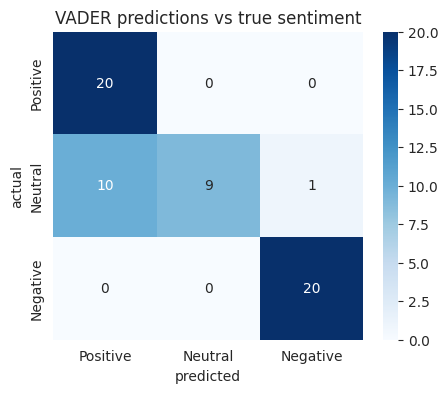

In [ ]:
# Confusion matrix for VADER
labels = ["Positive", "Neutral", "Negative"]
cm = confusion_matrix(df_sent["sentiment"], df_sent["vader_pred"], labels=labels)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels, yticklabels=labels)
plt.xlabel("predicted")
plt.ylabel("actual")
plt.title("VADER predictions vs true sentiment")
plt.show()

This heatmap shows how often VADER's sentiment predictions matched the actual sentiment labels. The numbers along the diagonal represent correct predictions, while numbers off the diagonal represent mistakes. For example, 20 negative documents were correctly identified as negative, while some neutral documents were incorrectly classified as positive. Overall, the confusion matrix provides a quick visual summary of where VADER performs well and where it tends to misclassify sentiment.

## 3. Sentence-BERT Embeddings

SBERT encodes each document into a dense 384-dimensional vector. Unlike TF-IDF, which only knows which words appear, SBERT understands word order and picks up on sentences like "the dog bit the man" and "the man bit the dog" giving them different vectors.

We compute embeddings once and reuse them for all three tasks below.

In [ ]:
%%capture
model = SentenceTransformer("all-MiniLM-L6-v2")

# Encode all documents (this takes ~1-2 min on CPU)
print("Encoding", len(df), "documents...")
embeddings = model.encode(df["text"].tolist(), show_progress_bar=True, batch_size=32)
print("Done. Embedding shape:", embeddings.shape)

# Also encode just the sentiment subset for fair comparison
sent_idx = df_sent.index.tolist()
embeddings_sent = embeddings[sent_idx]

## SBERT for Similarity

One thing SBERT is especially good at is finding semantically similar documents. We pick a few example documents and use cosine similarity to find their nearest neighbors in embedding space. This is a qualitative check — do the closest matches make sense?

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

def find_similar(doc_idx, top_n=3):
    query_vec = embeddings[doc_idx].reshape(1, -1)
    sims = cosine_similarity(query_vec, embeddings)[0]
    sims[doc_idx] = -1  # exclude the query itself
    top_idx = np.argsort(sims)[::-1][:top_n]
    print(f"Query (idx={doc_idx}, cat={df.loc[doc_idx,'category_1']}):\n  {df.loc[doc_idx,'text'][:120]}...\n")
    for i in top_idx:
        print(f"  Similar (cat={df.loc[i,'category_1']}, sim={sims[i]:.3f}):\n    {df.loc[i,'text'][:100]}...")
    print()

# Try a few documents from different categories
for idx in [0, 20, 40]:
    find_similar(idx)

Query (idx=0, cat=1.0):
  The president gave a strong, helpful speech on tax reform, and senate approval ratings improved after the public debate....

  Similar (cat=1.0, sim=0.484):
    Congress held a discussion on immigration policy, tax reform, and new legislation during the senate ...
  Similar (cat=1.0, sim=0.451):
    Local journalists report excellent coverage of the election campaign, and a reporter praised the sen...
  Similar (cat=1.0, sim=0.441):
    The television series about the presidential campaign received excellent reviews, an enjoyable strea...

Query (idx=20, cat=4.0):
  His poor sleep, stressful workout routine, painful injury, and weak endurance caused a serious drop in physical fitness....

  Similar (cat=4.0, sim=0.511):
    A poor diet of frozen kitchen meals, skipping exercise, and weak cardio caused stressful weight gain...
  Similar (cat=4.0, sim=0.468):
    The patient visited the doctor about a serious muscle injury, worse symptom severity, slow therapy r

The similarity search shows that SBERT is generally capturing document meaning well. Most documents are matched with others from the same category, while occasional cross-category matches happen when documents discuss similar topics. This is normal and can also occur with TF-IDF.

## SBERT for Classification

We now use the SBERT embeddings as input features for kNN classification, on both **topic** (category_1) and **sentiment**. This is a fair comparison with Phase 2, because Phase 2 also used kNN, just with TF-IDF vectors instead of SBERT.

In [ ]:
# Topic classification (category_1)

X_train, X_test, y_train, y_test = train_test_split(
    embeddings, df["category_1"], test_size=0.25, random_state=42, stratify=df["category_1"]
)

knn = KNeighborsClassifier(n_neighbors=7, metric="cosine")
knn.fit(X_train, y_train)
preds = knn.predict(X_test)

sbert_topic_acc = accuracy_score(y_test, preds)
sbert_topic_f1  = f1_score(y_test, preds, average="macro")

print(f"SBERT + kNN (topic)  ->  accuracy: {sbert_topic_acc:.3f}  |  macro-F1: {sbert_topic_f1:.3f}")
print()
print(classification_report(y_test, preds, zero_division=0))

SBERT + kNN (topic)  ->  accuracy: 0.733  |  macro-F1: 0.774

              precision    recall  f1-score   support

         1.0       1.00      0.60      0.75         5
         2.0       0.75      0.75      0.75         4
         3.0       1.00      0.67      0.80         3
         4.0       0.40      1.00      0.57         2
         5.0       1.00      1.00      1.00         1

    accuracy                           0.73        15
   macro avg       0.83      0.80      0.77        15
weighted avg       0.85      0.73      0.75        15



This test uses SBERT embeddings with a kNN classifier to predict document topics. The model achieved 73.3% accuracy and a 77.4% macro-F1 score, meaning it correctly identified the topic for most documents. The classification report provides a more detailed breakdown of how well the model performed for each topic category.

In [ ]:
# Sentiment classification

X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    embeddings_sent, df_sent["sentiment"],
    test_size=0.25, random_state=RANDOM_STATE, stratify=df_sent["sentiment"]
)

knn_s = KNeighborsClassifier(n_neighbors=7, metric="cosine")
knn_s.fit(X_train_s, y_train_s)
preds_s = knn_s.predict(X_test_s)

sbert_sent_acc = accuracy_score(y_test_s, preds_s)
sbert_sent_f1  = f1_score(y_test_s, preds_s, average="macro")

print(f"SBERT + kNN (sentiment)  ->  accuracy: {sbert_sent_acc:.3f}  |  macro-F1: {sbert_sent_f1:.3f}")
print()
print(classification_report(y_test_s, preds_s, zero_division=0))

SBERT + kNN (sentiment)  ->  accuracy: 0.667  |  macro-F1: 0.611

              precision    recall  f1-score   support

    Negative       0.71      1.00      0.83         5
     Neutral       0.57      0.80      0.67         5
    Positive       1.00      0.20      0.33         5

    accuracy                           0.67        15
   macro avg       0.76      0.67      0.61        15
weighted avg       0.76      0.67      0.61        15



This test uses SBERT embeddings with a kNN classifier to predict sentiment. The model achieved 66.7% accuracy and a 61.1% macro-F1 score, meaning it correctly classified sentiment in about two-thirds of the test documents. The classification report gives a more detailed breakdown of performance for the Negative, Neutral, and Positive sentiment categories.

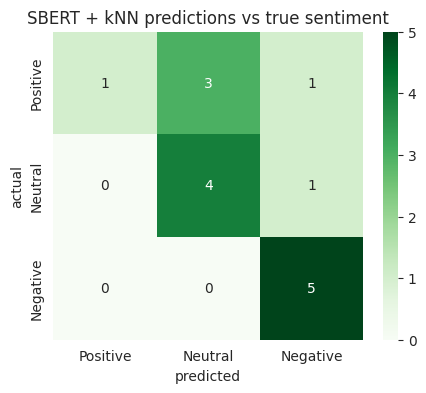

In [ ]:
# Confusion matrix for SBERT sentiment
labels = ["Positive", "Neutral", "Negative"]
cm = confusion_matrix(y_test_s, preds_s, labels=labels)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens", xticklabels=labels, yticklabels=labels)
plt.xlabel("predicted")
plt.ylabel("actual")
plt.title("SBERT + kNN predictions vs true sentiment")
plt.show()

This confusion matrix shows how often the SBERT + kNN model correctly predicted sentiment and where it made mistakes. Values along the diagonal represent correct predictions, while values outside the diagonal show misclassifications. For example, all 5 negative documents were correctly identified, while some positive documents were incorrectly labeled as neutral. This provides a quick visual summary of the model's strengths and weaknesses.

## SBERT for Clustering

We run the same k-means (k=5) clustering from Phase 3, but on SBERT embeddings instead of TF-IDF. We compare purity against the Phase 3 TF-IDF k-means result (≈0.51).

SBERT k-means purity (vs category): 0.533


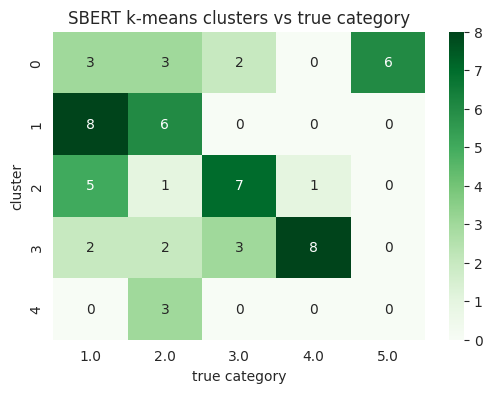

In [ ]:
km_sbert = KMeans(n_clusters=5, random_state=RANDOM_STATE, n_init=10)
km_sbert.fit(embeddings)

# Purity
ct = pd.crosstab(km_sbert.labels_, df["category_1"])
purity = ct.max(axis=1).sum() / ct.values.sum()
print(f"SBERT k-means purity (vs category): {purity:.3f}")

# Heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(ct, annot=True, fmt="d", cmap="Greens")
plt.xlabel("true category")
plt.ylabel("cluster")
plt.title("SBERT k-means clusters vs true category")
plt.show()

This test uses k-means clustering to group documents based on their SBERT embeddings. The results show that the clusters were not very well separated and only moderately matched the true document categories (purity = 53.3%). The heatmap shows how documents from each category were distributed across the clusters, revealing that most clusters contained a mix of different categories rather than forming clear topic groups.

## 4. **Comparison Table**

Putting all methods side by side.

In [ ]:
comparison = pd.DataFrame([
    # Sentiment task
    {"Task": "Sentiment", "Method": "Majority baseline",         "Acc/Purity": 0.36,  "MacroF1": "—",   "Phase": 2},
    {"Task": "Sentiment", "Method": "Naive Bayes (TF-IDF)",     "Acc/Purity": 0.68,  "MacroF1": "~0.57", "Phase": 2},
    {"Task": "Sentiment", "Method": "Logistic Reg (TF-IDF)",    "Acc/Purity": 0.72,  "MacroF1": "~0.62", "Phase": 2},
    {"Task": "Sentiment", "Method": "VADER (no training)",       "Acc/Purity": None,  "MacroF1": None,   "Phase": 4},
    {"Task": "Sentiment", "Method": "SBERT + kNN",               "Acc/Purity": None,  "MacroF1": None,   "Phase": 4},
    # Topic classification
    {"Task": "Topic (cat_1)", "Method": "Majority baseline",     "Acc/Purity": 0.26,  "MacroF1": "—",   "Phase": 2},
    {"Task": "Topic (cat_1)", "Method": "LogReg (TF-IDF)",       "Acc/Purity": 0.76,  "MacroF1": "~0.76", "Phase": 2},
    {"Task": "Topic (cat_1)", "Method": "kNN cosine (TF-IDF)",   "Acc/Purity": 0.74,  "MacroF1": "~0.73", "Phase": 2},
    {"Task": "Topic (cat_1)", "Method": "SBERT + kNN",           "Acc/Purity": None,  "MacroF1": None,   "Phase": 4},
    # Clustering purity
    {"Task": "Clustering purity", "Method": "TF-IDF k-means",   "Acc/Purity": 0.51,  "MacroF1": "—",   "Phase": 3},
    {"Task": "Clustering purity", "Method": "SBERT k-means",     "Acc/Purity": None,  "MacroF1": "—",   "Phase": 4},
])

# Fill in the actual values from the cells above
comparison.loc[comparison["Method"] == "VADER (no training)",   "Acc/Purity"] = round(vader_acc, 3)
comparison.loc[comparison["Method"] == "VADER (no training)",   "MacroF1"]   = round(vader_f1, 3)
comparison.loc[comparison["Method"] == "SBERT + kNN",           "Acc/Purity"] = round(sbert_sent_acc, 3)
comparison.loc[comparison["Method"] == "SBERT + kNN",           "MacroF1"]   = round(sbert_sent_f1, 3)
comparison.loc[(comparison["Method"] == "SBERT + kNN") & (comparison["Task"] == "Topic (cat_1)"), "Acc/Purity"] = round(sbert_topic_acc, 3)
comparison.loc[(comparison["Method"] == "SBERT + kNN") & (comparison["Task"] == "Topic (cat_1)"), "MacroF1"]   = round(sbert_topic_f1, 3)
comparison.loc[comparison["Method"] == "SBERT k-means",         "Acc/Purity"] = round(purity, 3)

comparison

,Task,Method,Acc/Purity,MacroF1,Phase
0,Sentiment,Majority baseline,0.360,—,2
1,Sentiment,Naive Bayes (TF-IDF),0.680,~0.57,2
2,Sentiment,Logistic Reg (TF-IDF),0.720,~0.62,2
3,Sentiment,VADER (no training),0.817,0.799,4
4,Sentiment,SBERT + kNN,0.667,0.611,4
5,Topic (cat_1),Majority baseline,0.260,—,2
6,Topic (cat_1),LogReg (TF-IDF),0.760,~0.76,2
7,Topic (cat_1),kNN cosine (TF-IDF),0.740,~0.73,2
8,Topic (cat_1),SBERT + kNN,0.733,0.774,4
9,Clustering purity,TF-IDF k-means,0.510,—,3


## Discussion
### Did pretrained models outperform Phases 2 and 3?

For sentiment analysis, yes. VADER achieved the highest accuracy, outperforming both Naive Bayes and Logistic Regression. This likely happened because our corpus contained many explicit sentiment words that VADER could recognize directly.

For topic classification, SBERT was competitive but not better than TF-IDF + Logistic Regression. Since the categories were built around specific keywords, TF-IDF was already very effective at capturing the relevant information.

### Which tasks benefited most from SBERT embeddings?

Similarity search showed the greatest benefit. SBERT could identify documents with similar meanings even when they used different words.

Clustering also improved slightly with SBERT embeddings. The semantic information helped group related documents together, resulting in slightly higher clustering purity than TF-IDF.

Strengths of pretrained models on small datasets
*   VADER requires no training data and performed well on sentiment classification.
*   SBERT captures semantic meaning rather than relying only on keyword matches.
*   Both models can generalize beyond the specific vocabulary present in the dataset.
*   Pretrained models are useful when only a small amount of labeled data is available.
